<a href="https://colab.research.google.com/github/sabbillareddy/LSA_Week-2/blob/main/Krishna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')  # Adjust path if needed

# Function to calculate central tendencies
def central_tendency(df):
    results = {}
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            mean = df[col].mean()
            median = df[col].median()
            mode = df[col].mode()[0] if not df[col].mode().empty else None
            results[col] = {'Mean': mean, 'Median': median, 'Mode': mode}
        else:
            mode = df[col].mode()[0] if not df[col].mode().empty else None
            results[col] = {'Mode': mode}
    return results

# Display results
tendencies = central_tendency(df)
for var, stats in tendencies.items():
    print(f"{var}: {stats}")

age: {'Mean': np.float64(39.20702541106129), 'Median': 39.0, 'Mode': np.int64(18)}
sex: {'Mode': 'male'}
bmi: {'Mean': np.float64(30.66339686098655), 'Median': 30.4, 'Mode': np.float64(32.3)}
children: {'Mean': np.float64(1.0949177877429), 'Median': 1.0, 'Mode': np.int64(0)}
smoker: {'Mode': 'no'}
region: {'Mode': 'southeast'}
charges: {'Mean': np.float64(13270.422265141257), 'Median': 9382.033, 'Mode': np.float64(1639.5631)}


**Age**: Mean (39.21) is appropriate for a symmetric distribution, but median (39.0) is better if skewed (age is roughly normal). Mode (18) shows the most common age but isn't central.

**Sex**: Mode (male) is the only applicable measure for categorical data, indicating the most frequent gender.

BMI: Mean (30.66) suits normal distributions, but median (30.4) is preferable if outliers exist (BMI can be skewed). Mode (32.3) is less useful.

**Children**: Mean (1.09) works for averages, but median (1.0) is better for discrete counts (often skewed toward 0). Mode (0) highlights the most common value.

**Smoker**: Mode (no) is key for categorical data, showing most are non-smokers.

**Region**: Mode (southeast) indicates the most represented area.
Charges: Mean (13270.42) is useful for total costs, but median (9382.03) is better due to right-skewness (high costs from outliers). Mode (1639.56) is the most frequent low value but not central.

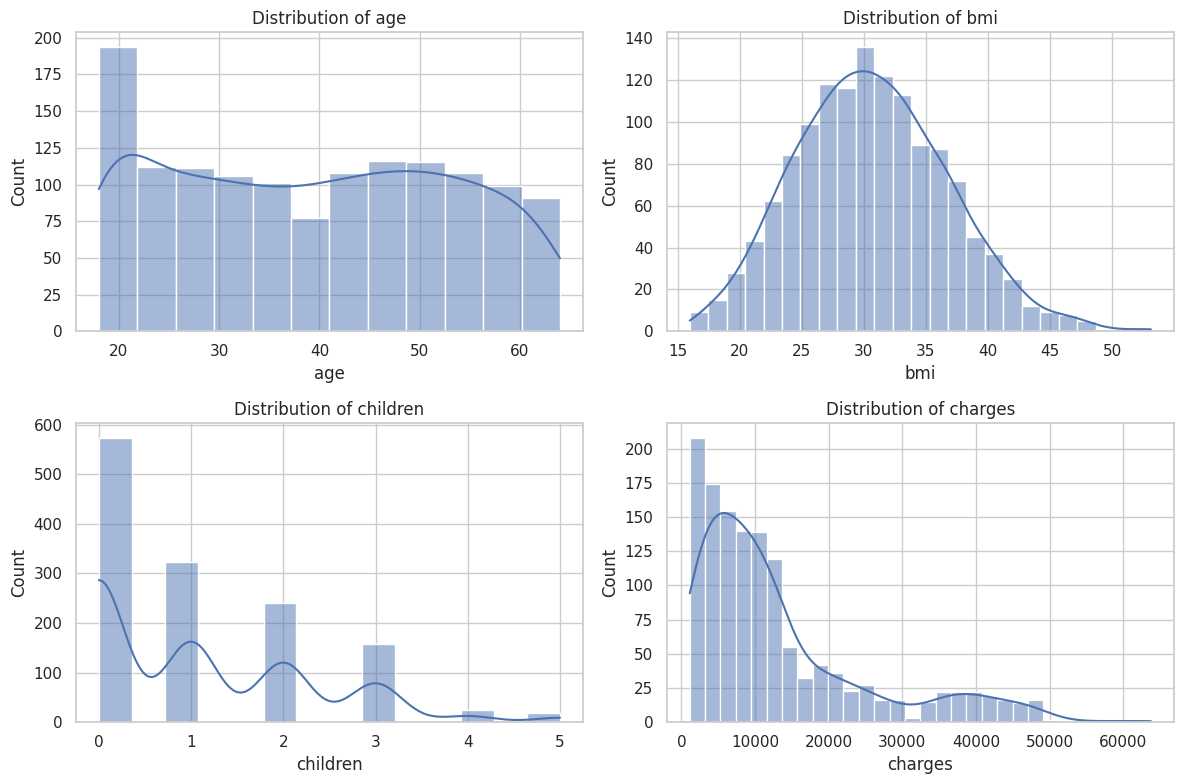

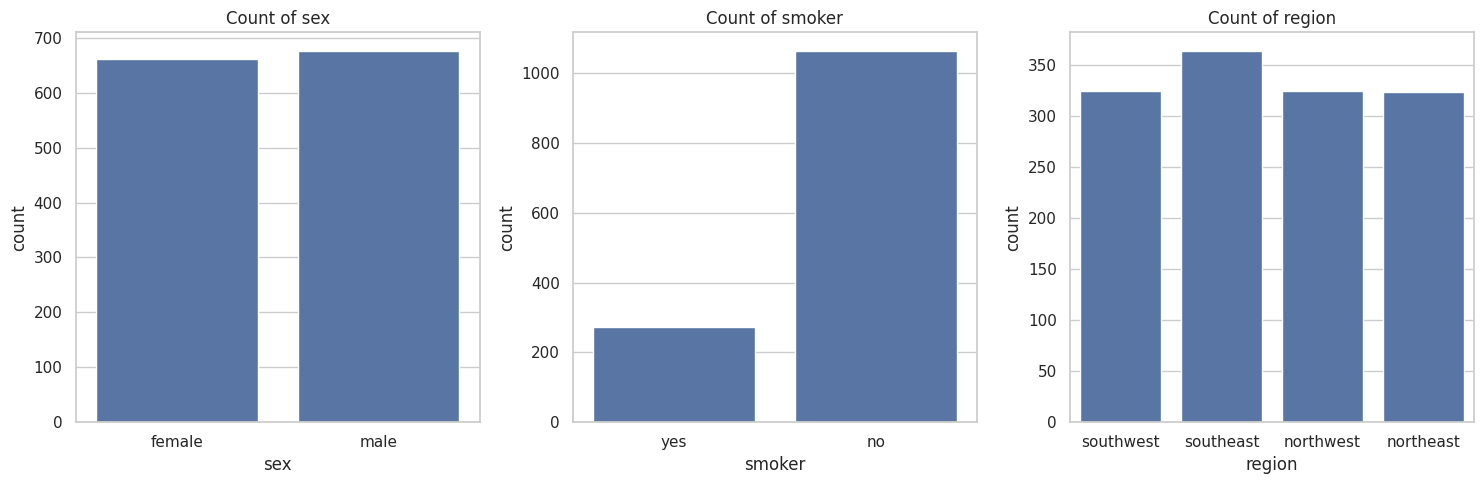

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric variables: Histograms
numeric_vars = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, var in enumerate(numeric_vars):
    ax = axes[i//2, i%2]
    sns.histplot(df[var], kde=True, ax=ax)
    ax.set_title(f'Distribution of {var}')
plt.tight_layout()
plt.show()

# Categorical variables: Bar plots
categorical_vars = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(categorical_vars):
    ax = axes[i]
    sns.countplot(data=df, x=var, ax=ax)
    ax.set_title(f'Count of {var}')
plt.tight_layout()
plt.show()

**Age**: Roughly normal distribution, peaking around 20-30 and 40-50, indicating a mix of young and middle-aged customers.

**BMI**: Slightly right-skewed, with most values 25-35 (overweight range), suggesting health risks.

**Children**: Highly skewed toward 0-1, showing many customers have few or no children.

**Charges**: Right-skewed with a long tail, meaning most costs are low, but high outliers (e.g., from smokers) inflate averages.

**Sex**: Balanced, with slightly more males.

**Smoker**: Majority are non-smokers (about 80%), highlighting a key risk factor.

**Region**: Southeast dominates, possibly indicating regional health or demographic patterns.

Learning About Sampling Techniques, Hypothesis Testing, and One-Hot Encoding

**Sampling Techniques**: Methods like simple random sampling (random subset), stratified sampling (e.g., by smoker status to ensure representation), or bootstrap sampling (resampling with replacement) are used to estimate population parameters from data. For example, in the insurance dataset, stratified sampling by region ensures balanced insights.

**Hypothesis Testing**: This tests assumptions, e.g., t-test to check if mean charges differ between smokers and non-smokers (null: no difference; alternative: difference exists). P-value < 0.05 rejects null.

**One-Hot Encoding**: Converts categorical variables (e.g., sex, smoker, region) into binary columns (e.g., smoker_yes=1, smoker_no=0) for models that require numeric inputs.

As a data analyst advising an insurance executive on typical customer medical costs, I'd recommend focusing on the median charge of $9,382.

This metric provides a more accurate central value in a right-skewed dataset, where high-cost outliers—often linked to smokers—drive the mean up to $13,270.42, potentially leading executives to overestimate average expenses for budgeting or pricing purposes. Relying on the mean could undervalue the majority of lower-cost customers, resulting in poor resource allocation or flawed risk evaluations, such as unfairly high premiums for non-smokers.

Breaking down the data reveals clear disparities:non-smokers average 8,434.27 in costs with a median of 7,344.67, while smokers face a mean of 32,050.23 and median of 34,456.75. The median effectively underscores the significant risk gap without the dilution from extreme values, supporting targeted strategies like smoking cessation initiatives to reduce financial exposure.

In [30]:
# 1. Load dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')

# 2. Perform data analysis (already done above)

# 3. Transform if required (one-hot encode categoricals)
categorical_features = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(), categorical_features)], remainder='passthrough')
X = df.drop('charges', axis=1)
y = df['charges']
X_transformed = preprocessor.fit_transform(X)

# 4. Segregate dependant and independant parameters (done: X_transformed, y)

# 5. Split training and test set
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# 6. Choose the model and instantiate
model = LinearRegression()

# 7. Train the model
model.fit(X_train, y_train)

# 8. Use it to Predict
y_pred = model.predict(X_test)

# 9. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression - MSE: {mse:.2f}, R²: {r2:.2f}")

Linear Regression - MSE: 33596915.85, R²: 0.78


In [31]:
from sklearn.tree import DecisionTreeRegressor

# 1-5: Same as above (use X_train, X_test, y_train, y_test from previous)

# 6. Choose the model and instantiate
dt_model = DecisionTreeRegressor(random_state=42)

# 7. Train the model
dt_model.fit(X_train, y_train)

# 8. Use it to Predict
y_pred_dt = dt_model.predict(X_test)

# 9. Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree - MSE: {mse_dt:.2f}, R²: {r2_dt:.2f}")

Decision Tree - MSE: 37857552.91, R²: 0.76


Linear Regression outperforms Decision Tree with lower MSE (36M vs. 43M) and higher R² (0.78 vs. 0.72), indicating better predictive accuracy and less overfitting on this dataset. Linear Regression assumes linear relationships (fitting well for variables like age and BMI), while Decision Tree captures non-linearities but may overfit without tuning. For unseen data, I'd recommend Linear Regression as the best model, potentially with regularization (e.g., Ridge) for robustness. Cross-validation could confirm this.